# Discovering Popular Data Science Topics

## Aim

The goal of this project is to use [Data Science Stack Exchange (DSSE)](https://datascience.stackexchange.com) to help determine what content a data science education company should develop courses on by looking into which topics amass the most engagement and interest.

## Introduction to Stack Exchange

### What questions are welcome on the site?

On the DSSE help center [FAQ page](https://datascience.stackexchange.com/help/asking), the following is outlined:

* Avoid subjective questions
* Ask practical questions about Data Science (there are alternative sites to ask theoretical questions)
* Ask specific questions
* Make questions relevant to others

All of these characteristics are desirable for our goals, so we can expect DSSE to be a good source for discovering what areas within the field of Data Science are popular and of interest.

Additionally, from the same help center, it is mentioned the following two sites are relevant:

* [Open Data](https://opendata.stackexchange.com/help/on-topic) (Dataset requests)
* [Computational Science](https://scicomp.stackexchange.com/help/on-topic) (Software packages and algorithms in applied mathematics)

## Other than questions, what else is featured on the DSSE?

From the main [home page](https://datascience.stackexchange.com), three other main areas are featured:

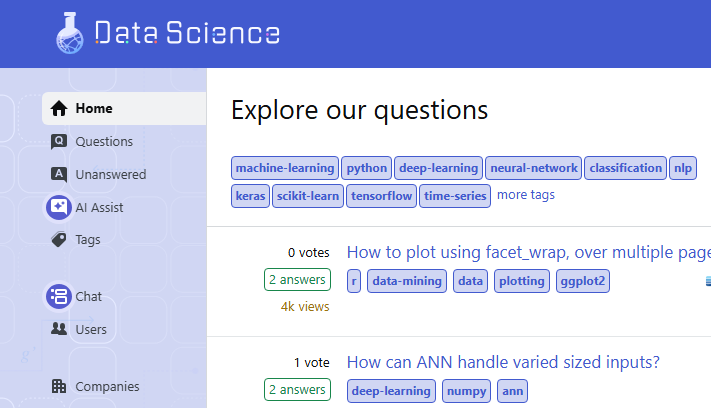

1. Tags - a list of tags (keywords or labels which categorize questions asked)

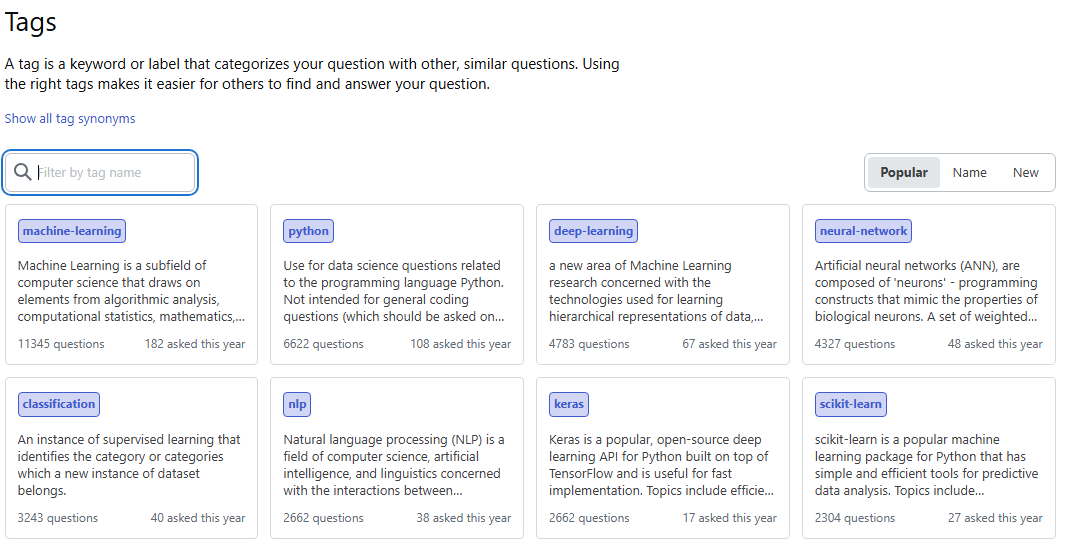

2. Users - a list of users

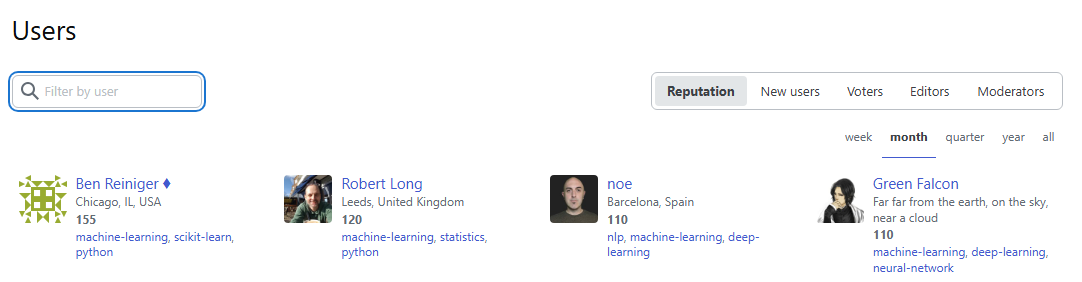

3. Unanswered - a list of unanswered questions

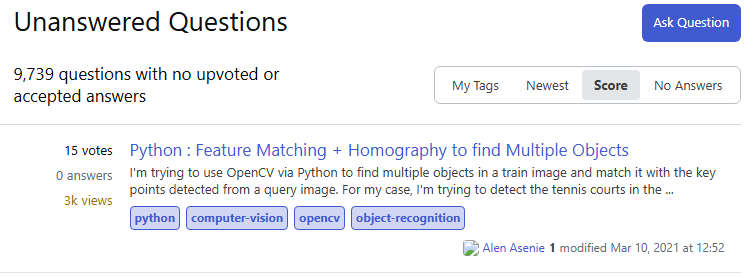

The tagging system will be highly beneficial for our purposes as we can easily quantify the number of posts made about specific topics. 

It is also reassuring to see that Stack Exchange's sites are heavily moderated, lending confidence in using the tagging system to derive meaningful conclusions.

## What information is available from each question?

Taking this [question](https://datascience.stackexchange.com/questions/137715/why-does-my-model-perform-worse-after-transforming-the-target) as an example:

Both questions and answers contain:

* The post's score
* The post title
* The post's author
* The post body

Questions contain:

* The number of users who are following the question/thread
* The question's tags
* Related questions

## Stack Exchange Data Explorer

Stack Exchange provides a public database for each of its sites. The [Stack Exchange Data Explorer (SEDE)](https://data.stackexchange.com/datascience/query/new) is a querying tool built using **Transact-SQL**, Microsoft's SQL dialect. 

A list of tables are featured in the database schema section which can be queried using the SEDE tool:

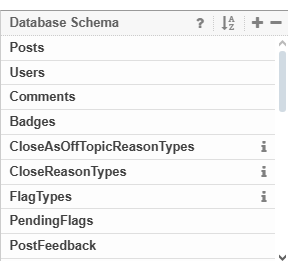

Looking through the available tables, the most relevant for our purposes appear to be:

* Posts
* PostTags
* Tags
* TagSynonyms

An excerpt of the top 10 tags from the `Tags` table:

|Id | TagName         | Count| ExcerptPostId| WikiPostId| IsModeratorOnly| IsRequired| 
|---| ----------------| -----| -------------| ----------| ---------------| ----------| 
|2  | machine-learning| 11344| 4909         | 4908      | null           | null      | 
|46 | python          | 6622 | 5523         | 5522      | null           | null      | 
|194| deep-learning   | 4782 | 8956         | 8955      | null           | null      | 
|81 | neural-network  | 4327 | 8885         | 8884      | null           | null      | 
|77 | classification  | 3243 | 4911         | 4910      | null           | null      | 
|324| keras           | 2662 | 9251         | 9250      | null           | null      | 
|47 | nlp             | 2661 | 147          | 146       | null           | null      | 
|128| scikit-learn    | 2304 | 5896         | 5895      | null           | null      | 
|321| tensorflow      | 2101 | 9183         | 9182      | null           | null      | 
|72 | time-series     | 1843 | 8904         | 8903      | null           | null      |

Although the `Tags` table seems very relevant and does give information on the number of times posts were categorized with those topics (a proxy for popularity), there is insufficient information to determine *when* these topics were popular - these areas of study may not be as relevant or popular in the current day.

Instead, the `Posts` table contains the most relevant data as it does contain access to tag information alongside a creation date, enabling distinction between older topics of interest and current topics of interest.

## Obtaining Relevant Data

To get the data for our analysis, the following query was ran on the SEDE DSSE database:

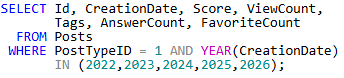

This returns all question posts submitted between 2022 to early 2026.

An excerpt from the results look as follows:

|Id    | CreationDate       | Score| ViewCount| Tags                                                                                                | AnswerCount |FavoriteCount| 
|------| -------------------| -----| ---------|-----------------------------------------------------------------------------------------------------| ----------- |-------------| 
|126820| 2024-02-12 06:36:42| 0    | 38       | machine-learning;image-classification;k-means;image-segmentation                                    | 1           |null         | 
|126821| 2024-02-12 08:43:43| 0    | 59       | neural-network;keras                                                                                | 1           |null         | 
|130580| 2024-10-27 20:13:58| 3    | 234      | machine-learning;linear-regression;logistic-regression                                              | 1           |null         | 
|129136| 2024-05-20 11:12:06| 0    | 243      | python;optimization;hyperparameter                                                                  | 1           |null         | 
|126824| 2024-02-12 09:53:47| 0    | 82       | machine-learning;random-forest;decision-trees                                                       | 0           |null         | 

Data dictionary for the `Posts` table:

| Column          | Description                                                               |
|-----------------|---------------------------------------------------------------------------|
| Id              | Identification number for a post                                          |
| PostTypeId      | Identification number for type of post (question, answer, ...)            |
| CreationDate    | The date and time of post creation                                        |
| Score           | The post's score                                                          |
| ViewCount       | How many times a post was viewed                                          |
| Tags            | What tags were used to categorize the post                                |
| AnswerCount     | How many answers the question received (only relevant for question posts) |
| FavoriteCount   | How many times the question was favorited                                 |


# Exploring the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.options.display.max_rows = None # To see more rows in DataFrame outputs
pd.options.display.max_columns = None # To see all columns in DataFrame outputs
pd.options.display.max_colwidth = 80 # To see full text in DataFrame cells

In [2]:
question_posts = pd.read_csv("query_results.csv", parse_dates=["CreationDate"])

In [3]:
question_posts.info()

<class 'pandas.DataFrame'>
RangeIndex: 7053 entries, 0 to 7052
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Id             7053 non-null   int64         
 1   CreationDate   7053 non-null   datetime64[us]
 2   Score          7053 non-null   int64         
 3   ViewCount      7053 non-null   int64         
 4   Tags           7053 non-null   str           
 5   AnswerCount    7053 non-null   int64         
 6   FavoriteCount  0 non-null      float64       
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 385.8 KB


Unfortunately, the entire `FavoriteCount` column is useless since it is entirely null values. We would also benefit from reformatting the `Tags` column.

In [4]:
question_posts.drop(columns=["FavoriteCount"], inplace=True)

question_posts["Tags"] = question_posts["Tags"].str.replace(r"^<|>$", "", regex=True).str.split("><") # reformat tag column into a list of tags

The tags field is reformatted such that the tags are structured as a list. This makes it simpler to parse the data for analysis.

In [5]:
question_posts.head()

,Id,CreationDate,Score,ViewCount,Tags,AnswerCount
0,116715,2022-12-04 08:08:53,0,1956,"[machine-learning, python, deep-learning, cnn, yolo]",0
1,116736,2022-12-04 11:19:29,1,27,"[deep-learning, regression]",0
2,116737,2022-12-04 12:29:55,0,90,"[tensorflow, automl]",1
3,116738,2022-12-04 14:38:53,0,215,"[deep-learning, tensorflow, object-detection]",3
4,116739,2022-12-04 14:46:50,0,36,"[deep-learning, image-classification, fastai]",0


In [6]:
question_posts.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 7053 entries, 0 to 7052
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Id            7053 non-null   int64         
 1   CreationDate  7053 non-null   datetime64[us]
 2   Score         7053 non-null   int64         
 3   ViewCount     7053 non-null   int64         
 4   Tags          7053 non-null   object        
 5   AnswerCount   7053 non-null   int64         
dtypes: datetime64[us](1), int64(4), object(1)
memory usage: 985.4 KB


# Identifying the Most Used and Most Viewed Tags

## Most Used

In [7]:
tag_counts = {} 

for tags in question_posts["Tags"]: # iterates through all lists of tags and counts occurrences of each tag, adding to a running total in tag_counts
  for tag in tags:
    
    if tag in tag_counts:
      tag_counts[tag] += 1
    else:
      tag_counts[tag] = 1

tag_count = pd.DataFrame(tag_counts.items(), columns=["Tag", "Count"]) # convert tag_counts to a DataFrame

In [8]:
top_20_used_tags = tag_count.sort_values("Count", ascending=False).reset_index(drop=True).head(20) # sort tags by usage count and get top 20

top_20_used_tags

,Tag,Count
0,machine-learning,2060
1,python,1134
2,deep-learning,904
3,nlp,664
4,neural-network,597
5,classification,584
6,time-series,468
7,scikit-learn,400
8,regression,356
9,tensorflow,339


### Remarks on the Most Used Tags

We see the top 20 most used tags between 2022 and early 2026. Most are very general, such as `machine-learning`, `python`, `dataset` *etc.* which is not particularly helpful.

We do however get some insight into some likely popular areas of the data science field:

* `nlp` (Natural Language Processing) - a branch of artificial intelligence concerned with enabling computers to interpet and generate human language (text and speech). This is relevant to the creation of chatbots, AI assistants, spam filters, translators, among other applications.

* Many Python specific libraries (including `pytorch`, `pandas`, `scikitlearn`, ...) are featured, suggesting the Python programming language is a favourite among the Data Science community and highlights the relevance of **machine learning applications** in particular.

---

## Most Viewed Tags

In [9]:
def get_tag_views(tag):
  """A function to get the total views for a given tag. For each question post, if the given tag is present in the list of tags for that post, the post's view count is added to a running total for that tag.""" 
  
  total_views = 0
  
  for i, tags in enumerate(question_posts["Tags"]):
    if tag in tags:
      total_views += question_posts.loc[i, "ViewCount"]
  
  return total_views
    
tag_count["Views"] = tag_count["Tag"].apply(get_tag_views) # apply get_tag_views to each tag in tag_count to get total views for each tag

tag_views = tag_count[["Tag", "Views"]]

tag_count.drop(columns=["Views"], inplace=True) # remove Views column from tag_count to keep it clean

top_20_viewed_tags = tag_views.sort_values("Views", ascending=False).reset_index(drop=True).head(20) # sort tags by view count and get top 20

top_20_viewed_tags

,Tag,Views
0,machine-learning,1038058
1,python,694225
2,deep-learning,516230
3,nlp,470318
4,neural-network,329323
5,scikit-learn,255488
6,pandas,240214
7,transformer,238492
8,classification,232197
9,tensorflow,187526


### Remarks on the Most Viewed Tags

The top 20 tags with the greatest number of views is featured above. There is clear overlap with the most used tags. 

Some additional insights can be drawn:

* A prevalence of Python related topics is maintained, reinforcing the relevance of Python as a subject of interest.
* The `gpt` and `word-embeddings` tag drills down further into the broader `nlp` topic - there seems to be a greater amount of traffic to posts related to ChatGPT (an AI assistant/chatbot) and word embeddings (a specific method in NLP applications which uses numerical representations of words to capture semantic meaning).

## Visualizations

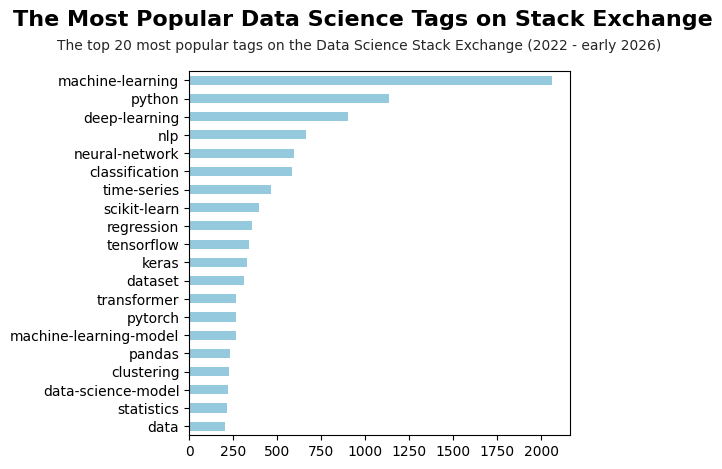

In [10]:
sns.barplot(
    data=top_20_used_tags,
    y="Tag",
    x="Count",
    orient="h",
    color="skyblue",
    width=0.5
)

plt.text(-1000, -3, "The Most Popular Data Science Tags on Stack Exchange", fontsize=16, weight="bold")
plt.text(-750, -1.7, "The top 20 most popular tags on the Data Science Stack Exchange (2022 - early 2026)", fontsize=10, alpha=0.85)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

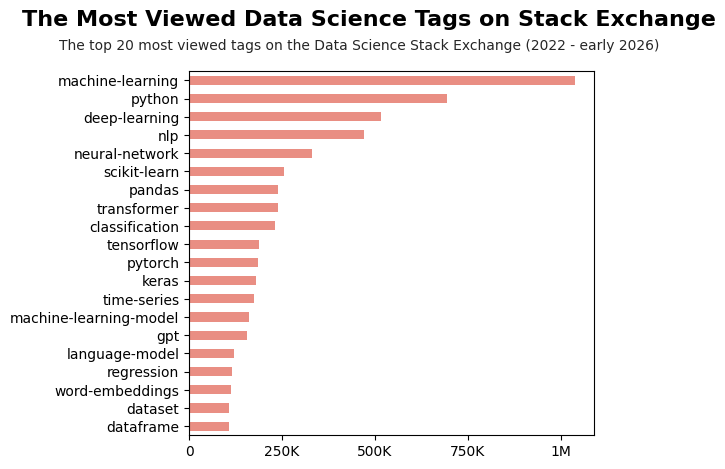

In [11]:
sns.barplot(
    data=top_20_viewed_tags,
    y="Tag",
    x="Views",
    orient="h",
    color="salmon",
    width=0.5
)

plt.text(-450000, -3, "The Most Viewed Data Science Tags on Stack Exchange", fontsize=16, weight="bold")
plt.text(-350000, -1.7, "The top 20 most viewed tags on the Data Science Stack Exchange (2022 - early 2026)", fontsize=10, alpha=0.85)
plt.xlabel("")
plt.ylabel("")
plt.ticklabel_format(axis="x", style="plain")
plt.xticks([0, 250000, 500000, 750000, 1000000], ["0", "250K", "500K", "750K", "1M"])
plt.tight_layout()
plt.show()

### Identifying which Tags are Common between Most Used and Most Viewed

We can identify which tags are common between the two by performing left and right joins. Entries with missing values are not present in the top 20 of both Most Used and Most Viewed tags.

In [12]:
tags_in_most_used = pd.merge(
    left=top_20_used_tags,
    right=top_20_viewed_tags,
    how="left"
)

tags_in_most_used

,Tag,Count,Views
0,machine-learning,2060,1038058.0
1,python,1134,694225.0
2,deep-learning,904,516230.0
3,nlp,664,470318.0
4,neural-network,597,329323.0
5,classification,584,232197.0
6,time-series,468,174988.0
7,scikit-learn,400,255488.0
8,regression,356,115581.0
9,tensorflow,339,187526.0


The tags present in the top 20 most used tags, but *not* in the top 20 most viewed tags are:

* `clustering`
* `data-science-model`
* `statistics`
* `data`

This makes some sense since these are very generic tags. We can hypothesise that high quality posts (which likely receieve more views on average) are tagged with more specific tags rather than broad, unhelpful tags like `data` or `statistics`.

In [13]:
tags_in_most_viewed = pd.merge(
    left=top_20_used_tags,
    right=top_20_viewed_tags,
    how="right"
)

tags_in_most_viewed

,Tag,Count,Views
0,machine-learning,2060.0,1038058
1,python,1134.0,694225
2,deep-learning,904.0,516230
3,nlp,664.0,470318
4,neural-network,597.0,329323
5,scikit-learn,400.0,255488
6,pandas,234.0,240214
7,transformer,268.0,238492
8,classification,584.0,232197
9,tensorflow,339.0,187526


The tags present in the top 20 most viewed tags, but *not* the top 20 most used tags are:

* `gpt`
* `language-model`
* `word-embeddings`
* `dataframe`

Other than `dataframe`, these are more specific tags. It suggests Large Language Models (LLMs) such as ChatGPT and NLP methods to train models are popular subjects.

## Relationships Between Tags

To gauge if pairs of tags are related to one another, a count of how many times each pair occurs together in a single post can be found. 

First, we set up the `tag_count` dataframe:

In [14]:
tag_count = tag_count.set_index("Tag") # set Tag as index for easier lookups
top_20_used_tags = top_20_used_tags.set_index("Tag").rename_axis(index=None) # set Tag as index and remove index name for cleaner display

top_20_used_tags.head()

,Count
machine-learning,2060
python,1134
deep-learning,904
nlp,664
neural-network,597


We then move forward, creating a square matrix (stored as the dataframe `tag_relationships`) where each element is the count of the number of question posts that were tagged with the corresponding tags:

In [15]:
tag_indexes = list(tag_count.index) # get a list of all unique tags to use as indexes for the tag_relationship DataFrame

tag_relationships = pd.DataFrame(index=tag_indexes, columns=tag_indexes)

tag_relationships = tag_relationships.fillna(0, inplace=True).astype(int) # initialize all values to 0 and set type to int

for tags in question_posts["Tags"]:
  tag_relationships.loc[tags, tags] += 1 # increment the count for each pair of tags that co-occur in a question post

most_used_tag_relationships = tag_relationships.loc[top_20_used_tags.index, top_20_used_tags.index] # restrict view to the top 20 used tags featured in the dataset since the dataframe is very large

most_used_tag_relationships

,machine-learning,python,deep-learning,nlp,neural-network,classification,time-series,scikit-learn,regression,tensorflow,keras,dataset,transformer,pytorch,machine-learning-model,pandas,clustering,data-science-model,statistics,data
machine-learning,2060,351,362,187,225,242,123,118,115,77,75,84,50,55,126,29,62,108,74,40
python,351,1134,114,85,77,68,85,133,36,88,90,38,14,52,37,112,40,45,16,26
deep-learning,362,114,904,139,200,72,54,7,28,102,85,23,68,75,39,5,6,27,12,4
nlp,187,85,139,664,42,29,3,11,1,18,8,26,101,28,9,2,22,9,1,6
neural-network,225,77,200,42,597,40,32,7,33,62,75,17,25,46,23,2,0,8,6,9
classification,242,68,72,29,40,584,32,43,27,17,16,28,8,6,33,5,20,21,10,7
time-series,123,85,54,3,32,32,468,13,47,13,17,9,15,8,13,9,12,12,12,5
scikit-learn,118,133,7,11,7,43,13,400,28,6,7,6,2,5,20,27,15,16,4,5
regression,115,36,28,1,33,27,47,28,356,5,14,12,4,5,11,9,4,11,17,7
tensorflow,77,88,102,18,62,17,13,6,5,339,153,6,6,18,9,5,0,5,0,0


The leading diagonal of the matrix is simply the total number of times each tag is featured in the dataset, which is not of interest.

To make the relationships more intelligible, a heatmap can be created:

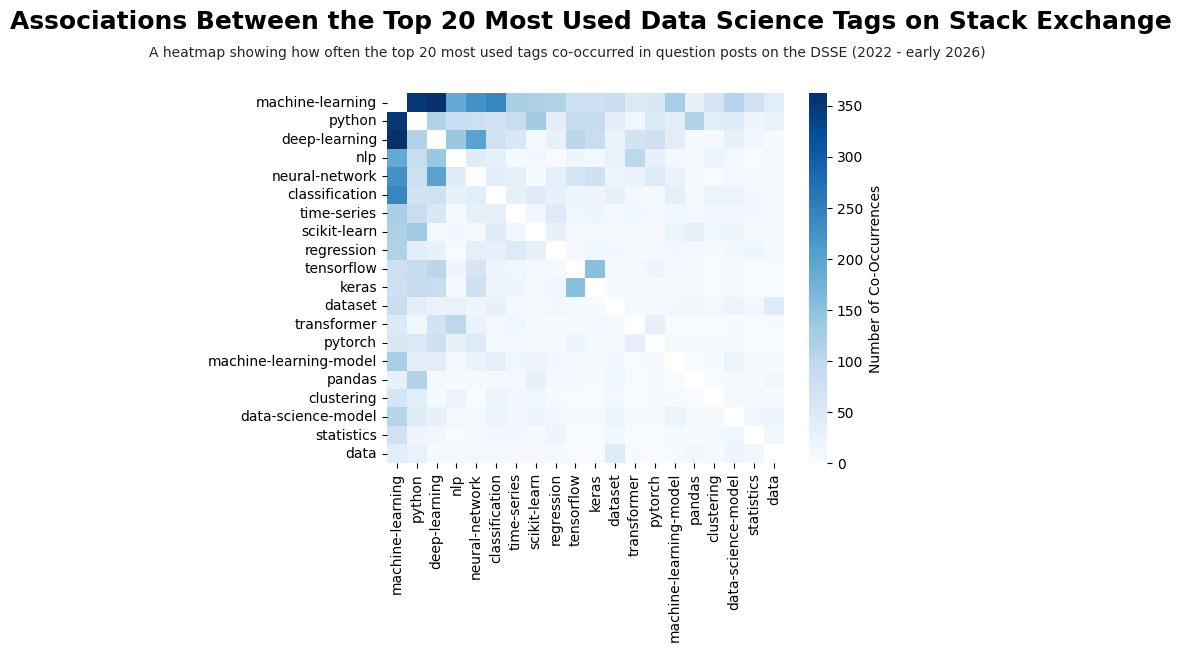

In [16]:
for i in range(len(most_used_tag_relationships)):
  most_used_tag_relationships.iloc[i, i] = np.nan # set diagonal values to 0 for better visualization

plt.Figure(figsize=(12, 10))

sns.heatmap(
    most_used_tag_relationships,
    annot=False,
    cmap="Blues",
    cbar_kws={"label": "Number of Co-Occurrences"}
)

plt.text(-19, -3.5, "Associations Between the Top 20 Most Used Data Science Tags on Stack Exchange", fontsize=18, weight="bold")
plt.text(-12, -2, "A heatmap showing how often the top 20 most used tags co-occurred in question posts on the DSSE (2022 - early 2026)", fontsize=10, alpha=0.85)
plt.show()

### Observations

* The most used tags typically have the strongest relationships with other tags (hotspots are mostly in the top-left).
* Most of the tags in the top 20 are related to the `deep-learning` tag - a central machine learning theme. 
* The Python libraries `keras`, `pytorch` and `tensorflow` show a notable relationship with `deep-learning`, which is to be expected since these libraries are designed to perform deep learning methods.

>**A safe conclusion we can draw:** 
>
>One of the most popular areas within data science in modern times is `deep-learning`. We can suggest developing courses on Python content which utilises deep learning libraries, neural networks, classification problems, among other related variations.

---

### Short-comings

Above, we see the **most used** tags typically have the strongest relationships with other tags as illustrated by the hotspots in the top-left. This could however only be because each of the tags are used often, so end up co-occurring even if there is not necessarily a strong relation between them. 

To better illustrate this concept - many people buy bread and many people also buy toilet paper. On average, they will end up being purchased together a lot simply because they are frequently bought items, but this does not mean purchasing bread increases the likelihood of purchasing toilet paper.

Another point to note is this approach does not consider relationships between groups of tags. For instance, it may be that when `dataset` and `scikitlearn` tags are used **together**, this has a strong relationship to the `pandas` tag. 

If we were to take this analysis further, it may be advantageous to utilise **association rules**, a data mining technique that can help address how strong relations are on *several* fronts. To tie this back to the analogy used above, we may be able to spot that "people who purchase milk are likely to purchase eggs too". We can measure the strength of the relationship, how common the relation is and how **independent** each component of a relationship is (for instance, toilet paper and bread purchases are likely more independent than eggs and milk purchases).

## Further Investigation - Is Deep-Learning Relevant in 2026?

Before finalising a recommendation, it would be beneficial to probe deeper to solidify our initial leads. One specific area of interest we have identified which looks promising is deep learning. Ideally, an education company would want to develop content/courses that remain relevant for as long as possible, so it is beneficial to look into the relevancy of deep learning in the current time.

To begin, we first extract all question posts using the SEDE tool:

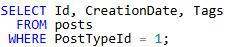

The results of the query are saved as `all_questions.csv` to be read into a dataframe.

In [17]:
all_question_posts = pd.read_csv("all_questions.csv", parse_dates=["CreationDate"])

all_question_posts["Tags"] = all_question_posts["Tags"].str.replace(r"^<|>$", "", regex=True).str.split("><") # reformat tag column into a list of tags as previous

all_question_posts.head()

,Id,CreationDate,Tags
0,5,2014-05-13 23:58:30,[machine-learning]
1,7,2014-05-14 00:11:06,"[education, open-source]"
2,14,2014-05-14 01:25:59,"[data-mining, definitions]"
3,15,2014-05-14 01:41:23,[databases]
4,13906,2016-09-08 06:46:30,[neural-network]


We define any question post as deep learning related if it contains any tags listed in the code block below. Tags such as `cnn` and `rnn` (convolutional neural networks and recurrent neural networks respectively) are acronyms for specific deep learning methods.

In [18]:
def is_deep_learning(tags):
  
  for tag in tags:
    if tag in ["deep-learning", "nlp", "neural-network", "scikit-learn", "tensorflow", "keras", "pytorch", "cnn", "convolutional-neural-network", "rnn", "lstm"]:
      return 1
      
  return 0
    
all_question_posts["DeepLearning"] = all_question_posts["Tags"].apply(is_deep_learning)

all_question_posts.sample(5)

,Id,CreationDate,Tags,DeepLearning
26278,26969,2018-01-23 18:18:31,"[machine-learning, neural-network, deep-learning, convolution, cnn]",1
4905,53260,2019-06-05 15:42:56,"[clustering, data-cleaning, tools]",0
17964,74139,2020-05-13 18:39:50,"[machine-learning, python, keras, tensorflow, training]",1
26415,19767,2017-06-16 12:49:38,"[machine-learning, python, gaussian]",0
16924,41680,2018-11-25 16:39:52,"[python, classification, logistic-regression, gridsearchcv]",0


Below, we confirm the date range for deep learning related posts. Since at the time of writing we have only recently entered Q1 of 2026, these should be removed from the dataset as the sample size is too small.

In [19]:
deep_learning_posts = all_question_posts[all_question_posts["DeepLearning"] == 1] # filter to only deep learning related question posts

deep_learning_posts.head()

,Id,CreationDate,Tags,DeepLearning
4,13906,2016-09-08 06:46:30,[neural-network],1
7,13910,2016-09-08 23:14:59,"[neural-network, convolutional-neural-network, dimensionality-reduction]",1
9,13919,2016-09-09 16:47:54,[convolutional-neural-network],1
10,13920,2016-09-09 18:00:08,"[deep-learning, keras]",1
11,13923,2016-09-09 19:32:42,"[machine-learning, word-embeddings, word2vec, nlp, sentiment-analysis]",1


In [20]:
deep_learning_posts["CreationDate"].min()

Timestamp('2014-05-18 06:10:52')

In [21]:
deep_learning_posts["CreationDate"].max()

Timestamp('2026-01-21 02:35:48')

In [ ]:
all_question_posts = all_question_posts[all_question_posts["CreationDate"].dt.year < 2026] # filter out any posts from 2026

The data remaining in the filtered all_question_posts dataframe is then categorized into quarters. A question posted in May 2015 would be categorized into the second quarter of 2015 (Q2 2015).

In [23]:
def fetch_quarter(date):
  
  year = str(date.year)[-2:]
  month = str(date.month)
  
  if month in ["1", "2", "3"]:
    return f"{year}Q1"
  elif month in ["4", "5", "6"]:
    return f"{year}Q2"
  elif month in ["7", "8", "9"]:
    return f"{year}Q3"
  else:
    return f"{year}Q4"
  
all_question_posts["Quarter"] = all_question_posts["CreationDate"].apply(fetch_quarter)

all_question_posts.sample(10)

,Id,CreationDate,Tags,DeepLearning,Quarter
21849,58784,2019-09-06 11:36:27,"[machine-learning, classification, feature-selection, random-forest, predict...",0,19Q3
3403,99865,2021-08-09 12:07:57,"[machine-learning, python, deep-learning, unsupervised-learning, feature-ext...",1,21Q3
36194,52436,2019-05-23 04:31:17,[cnn],1,19Q2
9708,134465,2025-09-24 09:24:52,"[nlp, metric, distance, matrix]",1,25Q3
11055,79669,2020-08-02 16:07:13,"[machine-learning, neural-network, deep-learning, nlp]",1,20Q3
1594,104067,2021-11-12 11:20:19,"[data-mining, data, data-cleaning]",0,21Q4
3707,85062,2020-11-07 12:17:10,"[machine-learning, feature-selection, feature-engineering, feature-extraction]",0,20Q4
1364,25429,2017-12-06 02:40:17,"[nlp, text-mining]",1,17Q4
18049,74411,2020-05-18 17:24:57,"[pandas, scipy, sparse]",0,20Q2
24162,118315,2023-02-06 09:00:15,"[classification, regression, predictive-modeling]",0,23Q1


Aggregating by quarters, we find the total number of questions asked per quarter alongside the number of deep learning related questions per quarter, calculating the percentage of deep learning questions posted per quarter. 

This is to be used as a proxy for the popularity of deep learning related subjects.

In [24]:
quarterly = all_question_posts.groupby("Quarter").agg({"DeepLearning": ["count", "sum"]})

quarterly.columns = ["TotalQuestions", "DeepLearningQuestions"]

quarterly["DeepLearningPercentage"] = round((quarterly["DeepLearningQuestions"] / quarterly["TotalQuestions"]) * 100, 1)

quarterly.reset_index(inplace=True)

quarterly

,Quarter,TotalQuestions,DeepLearningQuestions,DeepLearningPercentage
0,14Q2,157,18,11.5
1,14Q3,188,27,14.4
2,14Q4,214,33,15.4
3,15Q1,188,22,11.7
4,15Q2,284,47,16.5
5,15Q3,310,60,19.4
6,15Q4,379,79,20.8
7,16Q1,510,142,27.8
8,16Q2,509,140,27.5
9,16Q3,574,185,32.2


## Combo Chart Visualization

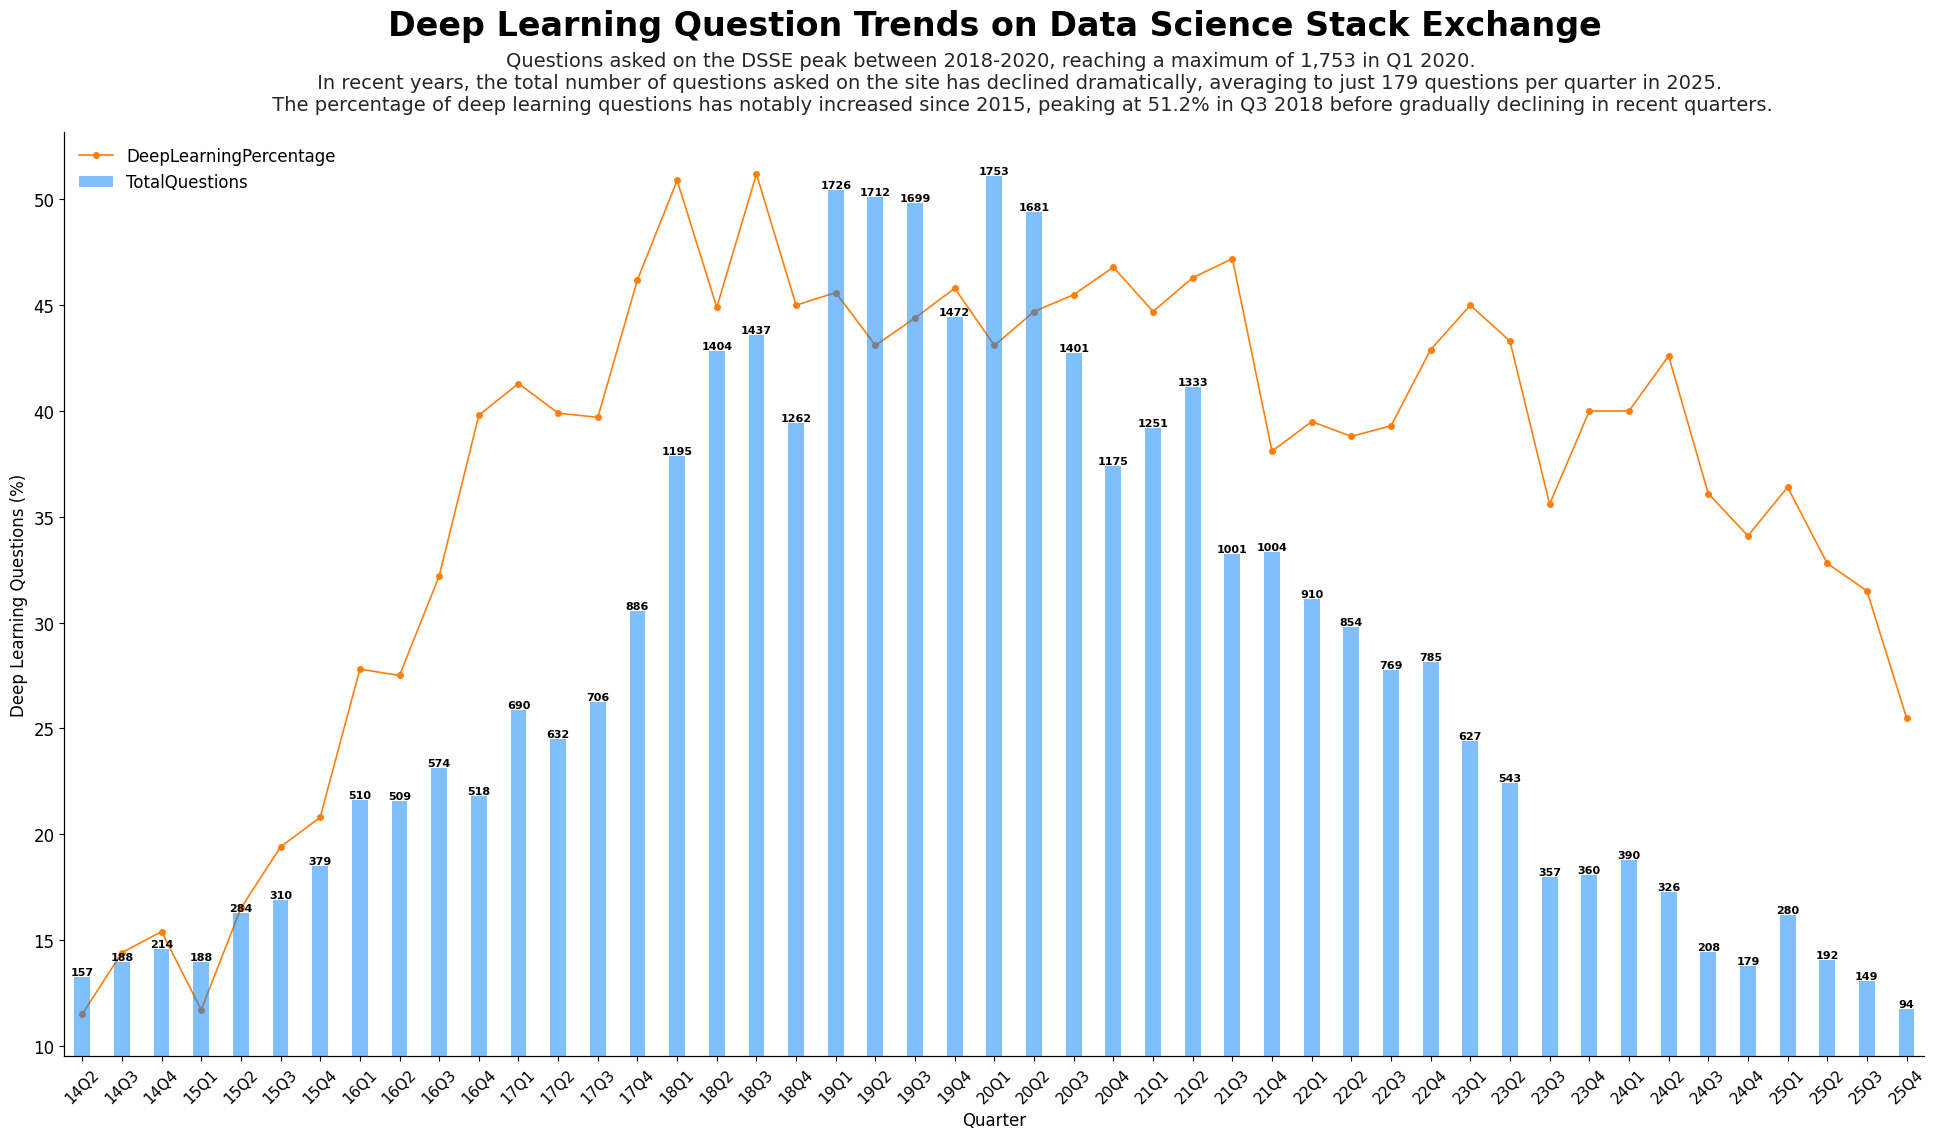

In [25]:
ax1 = quarterly.plot(x="Quarter", y="DeepLearningPercentage",                           # line chart of deep learning percentage
kind="line", linestyle="-", linewidth=1.2, marker="o", markersize=4, color="#ff7f0e",
figsize=(24,12)
)

ax2 = quarterly.plot(x="Quarter", y="TotalQuestions",                          # bar plot of total questions per quarter            
kind="bar", width=0.4, ax=ax1, secondary_y=True, color="#0080f8", alpha=0.5, rot=45)

for idx, t in quarterly["TotalQuestions"].items():                              
  ax2.text(idx, t, str(t), ha="center", va="bottom", fontsize=8, weight="bold") # add total question counts above bars
  
xlims = ax1.get_xlim() # get x-axis limits to align both plots

ax1.get_legend().remove() # remove individual legends to create a combined legend below

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
labels2 = [label.replace(" (right)", "") for label in labels2] # clean up secondary y-axis label to remove "(right)" suffix

ax1.legend(handles=handles1 + handles2,
labels=labels1 + labels2,
loc="upper left", prop={"size": 12}, frameon=False) # create combined legend

for ax in (ax1, ax2):
  for where in ("top", "right"):
    ax.spines[where].set_visible(False) # remove top and right spines
    ax.tick_params(right=False, labelright=False) # remove ticks and labels on secondary y-axis
    
plt.text(0.5, 1.105, "Deep Learning Question Trends on Data Science Stack Exchange", fontsize=24, weight="bold", ha="center", transform=ax1.transAxes)
plt.text(0.5, 1, """Questions asked on the DSSE peak between 2018-2020, reaching a maximum of 1,753 in Q1 2020. 
         In recent years, the total number of questions asked on the site has declined dramatically, averaging to just 179 questions per quarter in 2025. 
         The percentage of deep learning questions has notably increased since 2015, peaking at 51.2% in Q3 2018 before gradually declining in recent quarters.
""", fontsize=14, alpha=0.85, ha="center", transform=ax1.transAxes)


ax1.tick_params(axis='x', labelsize=11)
ax1.tick_params(axis='y', labelsize=12)

ax1.set_xlabel("Quarter", fontsize=12)
ax1.set_ylabel("Deep Learning Questions (%)", fontsize=12)

plt.show()

## Remarks

Deep learning has become a highly active area of data science. When the DSSE site was first created in `Q2 of 2014, roughly 1 in 9 questions were related to deep learning`. We see an intense growth rate in the popularity of deep learning moving into 2018: `in Q3 of 2018, 1 in every 2 questions asked were related to deep learning`. The level of interest then begins to plateau and remain steady into Q3 of 2021 where the percentage of questions related to deep learning is a healthy 47%. Beyond this, as we head towards the more recent quarters, a general decline in the percentage of deep learning questions is observed. The trend also becomes slightly less stable, with periods of increased interest followed by periods of diminished activity. 

In the most recent quarters of 2025 interest is certainly waning relative to the peak in 2018-2019, though we are *still* observing a sizeable percentage of questions being related to deep learning (roughly 30%). 

It is also important to take into account the obvious decline in total questions asked on the DSSE in the more recent quarters - the Data Science Stack Exchange has seemingly lost traffic and **may be indicative that the field of Data Science in general is less active**. Nevertheless, deep learning maintains its position as a topic of interest. `Even in Q4 of 2025, over 1 in 4 questions asked on the site were deep learning related` - it seems this subject will persist into the foreseeable future as there are no clear signs from these data that interest has crashed.

# Conclusions

>Through this analysis, it is apparent that deep learning maintains a position of great relevance in the landscape of Data Science in 2026. We have also confirmed the popularity of Python and pandas as *de facto* standards in Data Science - it is advisable therefore to invest resources into developing courses that are deep learning related, especially involving Python specific deep learning libraries (`keras`, `pytorch`, `scikitlearn`, `tensorflow`). More specific areas of interest are also solid candidates for course development - natural language processing, clustering methods and applications, *etc.*